In [1]:
import kagglehub
from torch.utils.data import random_split

# Download latest version
path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")

print("Path to dataset files:", path)

100%|██████████| 481M/481M [00:35<00:00, 14.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1


In [2]:
from torchvision import datasets, transforms
import os
import re # Import regex for parsing filenames
from torch.utils.data import Dataset
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        # First pass to collect all unique class names from filenames
        unique_class_names = set()
        for img_name in os.listdir(root_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                match = re.match(r'^([a-zA-Z]+)', img_name)
                if match:
                    class_name = match.group(1).lower()
                    unique_class_names.add(class_name)

        self.idx_to_class = sorted(list(unique_class_names))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.idx_to_class)}

        # Second pass to populate image_paths and labels
        for img_name in os.listdir(root_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                img_path = os.path.join(root_dir, img_name)
                match = re.match(r'^([a-zA-Z]+)', img_name)
                if match:
                    class_name = match.group(1).lower()
                    if class_name in self.class_to_idx:
                        self.image_paths.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])

        if not self.image_paths:
            raise RuntimeError(f"Found 0 images or could not parse any class names in: {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Define paths to the actual train, valid, and test directories based on file system inspection
train_dir = os.path.join(path, 'train', 'images')
valid_dir = os.path.join(path, 'valid', 'images')
test_dir = os.path.join(path, 'test', 'images')

# --- Debugging: List contents of train_dir ---
print(f"Contents of train_dir ({train_dir}):")
print(os.listdir(train_dir))
# ---------------------------------------------

# Create CustomImageDataset for each split
train_dataset = CustomImageDataset(root_dir=train_dir, transform=transform)
valid_dataset = CustomImageDataset(root_dir=valid_dir, transform=transform)
test_dataset = CustomImageDataset(root_dir=test_dir, transform=transform)

# Extract correct class names and number of classes from the training dataset
class_names = train_dataset.idx_to_class # Use idx_to_class from custom dataset
num_classes = len(class_names)

print("Actual Garbage Classes (for training):", class_names)
print("Number of actual classes:", num_classes)

# Note: The visualization cell (3xj4uUwUDAnK) that used a 'dataset' variable
# with incorrect class labels will no longer work after this change.

Contents of train_dir (/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/train/images):
['biodegradable633_jpg.rf.fa6e5473b825b61579dcefd2fdb299c6.jpg', 'plastic213_jpg.rf.bb92ed29b80074c6c3d28a116c45756f.jpg', 'paper2_jpg.rf.1a7d93c01908ae0f7356762eb0c10e97.jpg', 'biodegradable1796_jpeg.rf.01e2dc4cf140f0f8ccffb0d40fa414bf.jpg', 'metal437_jpeg.rf.277689e885c17a76ef6bfed48947e89f.jpg', 'glass701_jpg.rf.575621a020013c81a94c66bf2b34255d.jpg', 'metal229_jpg.rf.ce22245b3a364e69535a67e24f66c259.jpg', 'cardboard249_jpg.rf.c5e34ee787822d76afc3b09f05428f6d.jpg', 'metal354_jpg.rf.87b8bf2d08748b9a4f47d0af8b6cb4d9.jpg', 'cardboard1315_jpg.rf.6ca6605a3d651ff4ce7dbced85779e7a.jpg', 'paper189_jpg.rf.3e8013df52ecd05695dce356c2e7626d_dup0.jpg', 'paper277_jpg.rf.5d38e38a6823e30e56213e3e8248c37d.jpg', 'metal429_jpg.rf.aa9044016cd9261bcc3938b4d2dee119.jpg', 'biodegradable797_jpg.rf.772b960af7049e78ee5c039fb45a2065.jpg', 'glass1496_jpg.rf.9c82d273b51cfa1aa58e0eb6c170eddd.jp

In [3]:
import os
print(os.listdir(path))
for root, dirs, files in os.walk(path):
    print(root)
    for d in dirs:
        print(os.path.join(root, d))
    for f in files:
        print(os.path.join(root, f))
    break # Only list the top level for now to avoid too much output

['data.yaml', 'test', 'valid', 'train', 'README.roboflow.txt', 'README.dataset.txt']
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/test
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/valid
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/train
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/data.yaml
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/README.roboflow.txt
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/README.dataset.txt


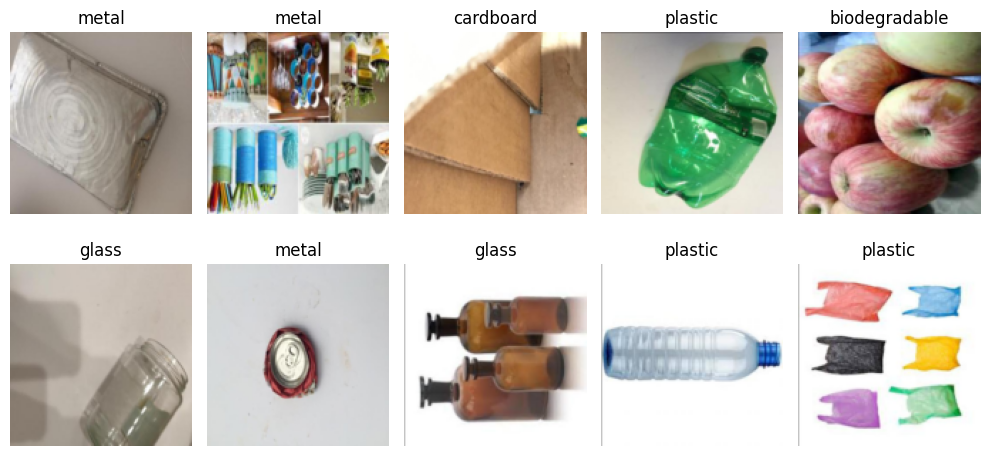

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random

plt.figure(figsize=(10, 5))

for i in range(10):
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]

    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(train_dataset.idx_to_class[label]) # Use train_dataset.idx_to_class
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import torch
# The calculation of class_weights has been moved to the cell where the criterion is defined to ensure proper device assignment.

In [6]:
# The datasets are already correctly split by folder structure
# The random_split logic is no longer needed.

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 18649
Validation dataset size: 2113
Test dataset size: 2246


In [7]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_classes): # num_classes is now a parameter
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
import torch
import torch.nn as nn # Ensure nn is imported for CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes=num_classes).to(device) # Pass the correct num_classes

# Calculate class weights and move to device using labels from the correctly loaded train_dataset
labels = [label for _, label in train_dataset]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels), # This will now yield 6 unique classes (0-5)
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [9]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.3
)

In [10]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for epoch in range(10):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step(train_loss)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch 0, Loss: 839.9145, Accuracy: 49.71%
Epoch 1, Loss: 739.3071, Accuracy: 56.22%
Epoch 2, Loss: 744.1815, Accuracy: 55.27%
Epoch 3, Loss: 730.8940, Accuracy: 56.79%
Epoch 4, Loss: 798.7518, Accuracy: 51.27%
Epoch 5, Loss: 799.0068, Accuracy: 49.60%
Epoch 6, Loss: 792.9389, Accuracy: 51.38%
Epoch 7, Loss: 739.8098, Accuracy: 53.40%
Epoch 8, Loss: 684.3964, Accuracy: 57.80%
Epoch 9, Loss: 646.6331, Accuracy: 60.20%


In [11]:
if 'model' not in globals():
    raise NameError("The 'model' variable is not defined. Please ensure the preceding cells, especially the one initializing the model (e.g., cell Ptr6jUneEVVV), have been executed.")

model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 68.4423, Test Accuracy: 65.45%


In [12]:
import torch
# Lưu model đã train ở cell trước đó
torch.save(model.state_dict(), 'garbage_model.pt')
print("Đã lưu mô hình vào file garbage_model.pt")

Đã lưu mô hình vào file garbage_model.pt


In [13]:
!pip install flask pyngrok flask-ngrok

In [17]:
import os
from flask import Flask, render_template, request, jsonify
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
import io
import base64

# Khởi tạo Flask
app = Flask(__name__, template_folder='templates')

# Định nghĩa lại kiến trúc để load (đảm bảo giống hệt class CNNModel đã định nghĩa)
# (Giả sử CNNModel đã được định nghĩa ở các cell trước)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model = CNNModel(num_classes=len(class_names))
inference_model.load_state_dict(torch.load('garbage_model.pt', map_location=device))
inference_model.to(device)
inference_model.eval()

# Transform cho ảnh input
inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

@app.route('/', methods=['GET'])
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'})

    file = request.files['file']
    img_bytes = file.read()
    image = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Tiền xử lý và dự đoán
    input_tensor = inference_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        class_idx = predicted.item()
        label = class_names[class_idx]

    # Chuyển ảnh sang base64 để hiển thị lại trên web
    encoded_img = base64.b64encode(img_bytes).decode('utf-8')

    return jsonify({
        'prediction': label,
        'image': encoded_img
    })

# Tạo thư mục templates và file index.html
if not os.path.exists('templates'):
    os.makedirs('templates')

with open('templates/index.html', 'w') as f:
    f.write('''
<!DOCTYPE html>
<html>
<head>
    <title>Garbage Classification CNN</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.1.3/dist/css/bootstrap.min.css" rel="stylesheet">
</head>
<body class="container mt-5">
    <h2 class="text-center">Nhận diện Rác thải bằng CNN</h2>
    <div class="row justify-content-center mt-4">
        <div class="col-md-6">
            <input type="file" id="imageInput" class="form-control" accept="image/*">
            <button onclick="uploadImage()" class="btn btn-primary mt-3 w-100">Phân loại ảnh</button>
        </div>
    </div>
    <div id="result" class="text-center mt-5" style="display:none;">
        <h4>Kết quả: <span id="label" class="badge bg-success"></span></h4>
        <img id="preview" src="" class="img-fluid mt-3" style="max-height: 300px;">
    </div>

    <script>
        async function uploadImage() {
            let fileInput = document.getElementById('imageInput');
            if (fileInput.files.length === 0) return alert('Hãy chọn một tấm ảnh!');

            let formData = new FormData();
            formData.append('file', fileInput.files[0]);

            let response = await fetch('/predict', { method: 'POST', body: formData });
            let data = await response.json();

            document.getElementById('result').style.display = 'block';
            document.getElementById('label').innerText = data.prediction;
            document.getElementById('preview').src = 'data:image/jpeg;base64,' + data.image;
        }
    </script>
</body>
</html>
''')


In [19]:
from pyngrok import ngrok
import threading

# 1. Nhập Authtoken của bạn vào đây (Lấy tại: https://dashboard.ngrok.com/get-started/your-authtoken)
# !!! HÃY ĐẢM BẢO THAY THẾ 'YOUR_NGROK_AUTH_TOKEN_HERE' BẰNG AUTHTOKEN THẬT CỦA BẠN !!!
NGROK_AUTH_TOKEN = "3BwEcnNPOUdh38OrcjbV8iI8dRS_4WqJ1KG4bU4Acmt34n7Sw"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 2. Mở tunnel ngrok
public_url = ngrok.connect(5000)
print(f" * Ngrok Tunnel URL: {public_url}")

# 3. Chạy Flask trong một luồng riêng biệt để không chặn Notebook
def run_app():
    app.run(port=5000, use_reloader=False)

threading.Thread(target=run_app).start()

 * Ngrok Tunnel URL: NgrokTunnel: "https://noteworthy-nonrupturable-olympia.ngrok-free.dev" -> "http://localhost:5000"
